# Task 3: Customer Churn Prediction (Bank Customers)

## Objective
Identify customers who are likely to leave the bank using classification models.

## Dataset
Churn Modelling Dataset — contains bank customer information such as geography,
gender, age, balance, and whether they exited (churned) or not.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv('Churn_Modelling.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Check data types and missing values
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing Values:
RowNumber          0
CustomerId         0
Surname            0


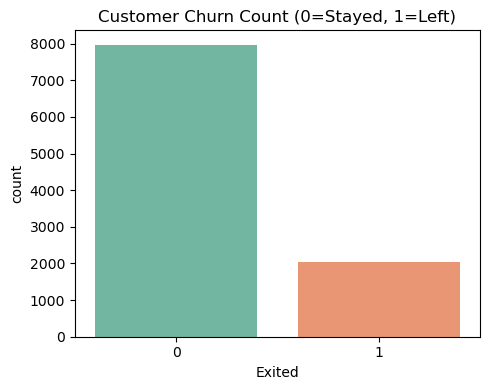

In [4]:
# Plot 1: Churn Count
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Exited', palette='Set2')
plt.title('Customer Churn Count (0=Stayed, 1=Left)')
plt.tight_layout()
plt.savefig('churn_count.png')
plt.show()

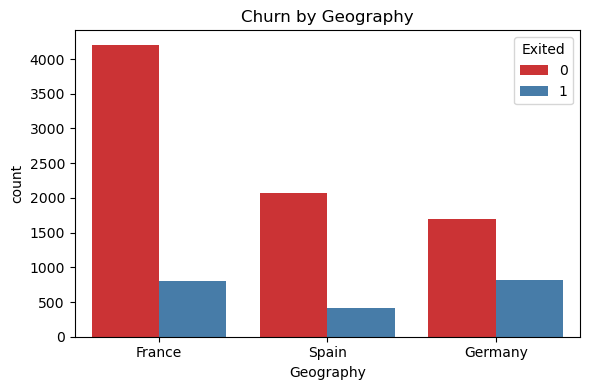

In [5]:
# Plot 2: Churn by Geography
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Geography', hue='Exited', palette='Set1')
plt.title('Churn by Geography')
plt.tight_layout()
plt.savefig('churn_geography.png')
plt.show()

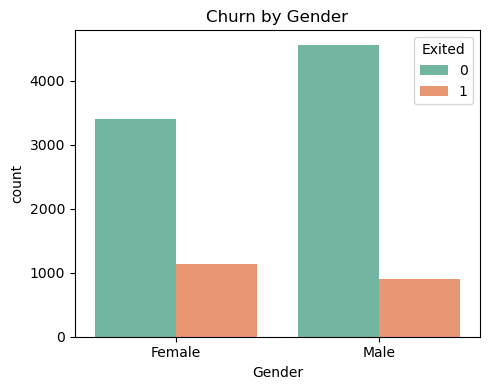

In [6]:
# Plot 3: Churn by Gender
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Gender', hue='Exited', palette='Set2')
plt.title('Churn by Gender')
plt.tight_layout()
plt.savefig('churn_gender.png')
plt.show()

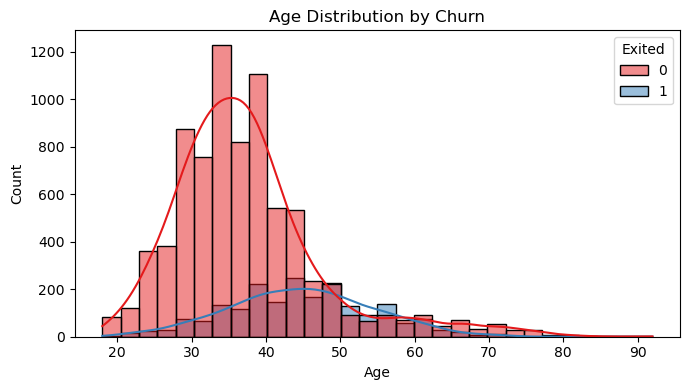

In [7]:
# Plot 4: Age Distribution by Churn
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True, palette='Set1')
plt.title('Age Distribution by Churn')
plt.tight_layout()
plt.savefig('churn_age.png')
plt.show()

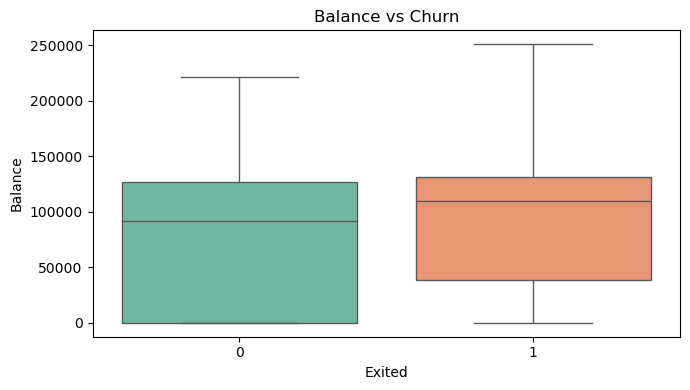

In [8]:
# Plot 5: Balance by Churn
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Exited', y='Balance', palette='Set2')
plt.title('Balance vs Churn')
plt.tight_layout()
plt.savefig('churn_balance.png')
plt.show()

In [9]:
# Drop columns that are not useful for prediction
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("Remaining columns:", df.columns.tolist())

Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [10]:
# Encode Gender using Label Encoding (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Encode Geography using One-Hot Encoding
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print("Encoding done! Sample data:")
df.head()

Encoding done! Sample data:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [11]:
# Define features (X) and target (y)
X = df.drop(columns=['Exited'])
y = df['Exited']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (8000, 11)
Testing set size: (2000, 11)


In [12]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluate
print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

=== Random Forest ===
Accuracy: 86.6 %

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [13]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Accuracy: 81.45 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.58      0.21      0.31       393

    accuracy                           0.81      2000
   macro avg       0.71      0.59      0.60      2000
weighted avg       0.78      0.81      0.78      2000



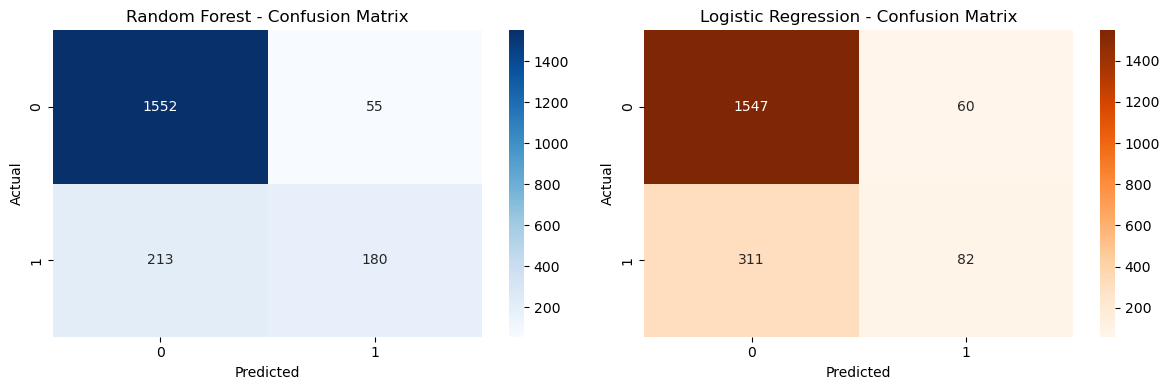

In [14]:
# Confusion Matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Random Forest
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Logistic Regression - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('churn_confusion_matrices.png')
plt.show()

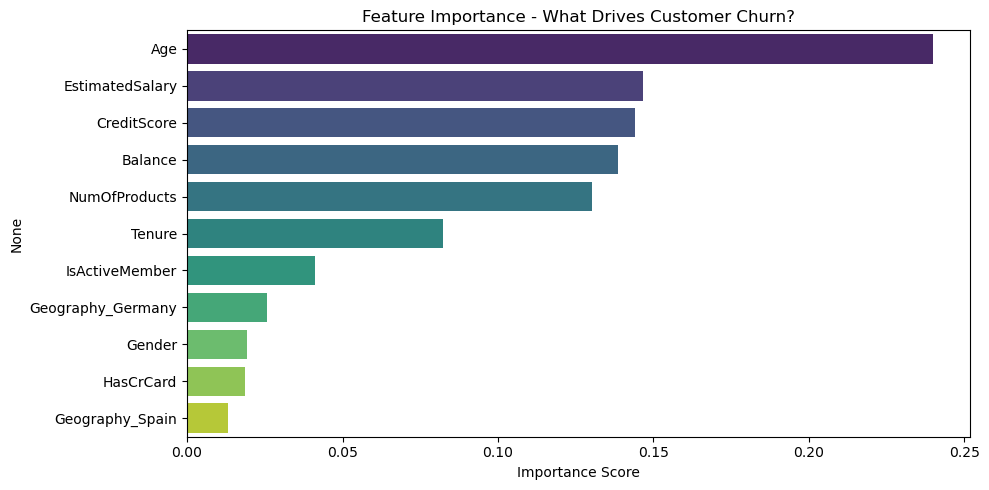

Top 5 most important features:
Age                0.239783
EstimatedSalary    0.146638
CreditScore        0.144214
Balance            0.138613
NumOfProducts      0.130255
dtype: float64


In [15]:
# Feature Importance from Random Forest
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title('Feature Importance - What Drives Customer Churn?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("Top 5 most important features:")
print(feature_importance.head())

## Conclusion

- The dataset has **10,000 rows** and **14 columns** with **no missing values**.
- About **20% of customers** churned — the dataset is slightly imbalanced.
- **Age** is the most important feature — older customers are more likely to churn.
- **Balance** also plays a key role — customers with higher balances tend to leave more.
- **Germany** has the highest churn rate compared to France and Spain.
- **Random Forest** outperformed Logistic Regression on this dataset.
- The bank should focus on retaining older, high-balance customers in Germany.